In [1]:
import sys

In [2]:
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import RAW_DATA_PATH,PROCESSED_DATA_PATH,TARGET_COLUMN,save_csv
from src.preprocessing import run_preprocessing
from src.features import engineer_features,get_feature_lists
sns.set_theme(style="whitegrid")
%matplotlib inline

# Clean the row data

In [3]:
df_clean=run_preprocessing(RAW_DATA_PATH)
df_clean.isna().sum().sum(),df_clean.shape

2026-07-09 14:16:25 | INFO     | src.preprocessing | Loading raw data from C:\Users\mohit\Credit-scoring-model\data\raw\credit_data.csv
2026-07-09 14:16:25 | INFO     | src.preprocessing | Loaded 1000 rows, 21 columns
2026-07-09 14:16:25 | INFO     | src.preprocessing | Dropped 0 duplicate rows


(np.int64(0), (1000, 21))

# Engineer financial ratios features

In [4]:
df_features=engineer_features(df_clean)
df_features.head()

2026-07-08 18:16:00 | INFO     | src.features | Feature engineering complete -> 24 columns


,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target,credit_mix_score,installment_amount,age_bucket
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good,0.029851,194.833301,65+
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,own,1,skilled employee/ official,1,none,yes,bad,0.045455,123.979164,<25
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,own,1,unskilled - resident,2,none,yes,good,0.020408,174.666652,45-55
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,for free,1,skilled employee/ official,2,none,yes,good,0.022222,187.666662,35-45
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,for free,2,skilled employee/ official,2,none,yes,bad,0.037736,202.916658,45-55


In [5]:
new_cols=[c for c in df_features.columns if c not in df_clean.columns]
print('New engineered features:',new_cols)
df_features[new_cols].describe(include='all').T

New engineered features: ['credit_mix_score', 'installment_amount', 'age_bucket']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
credit_mix_score,1000.0,NaN,NaN,NaN,0.04245,0.019034,0.013333,0.028571,0.038462,0.051619,0.148148
installment_amount,1000.0,NaN,NaN,NaN,167.687008,153.490937,24.055554,89.599992,130.333321,206.183306,2482.666253
age_bucket,1000,6,25-35,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN


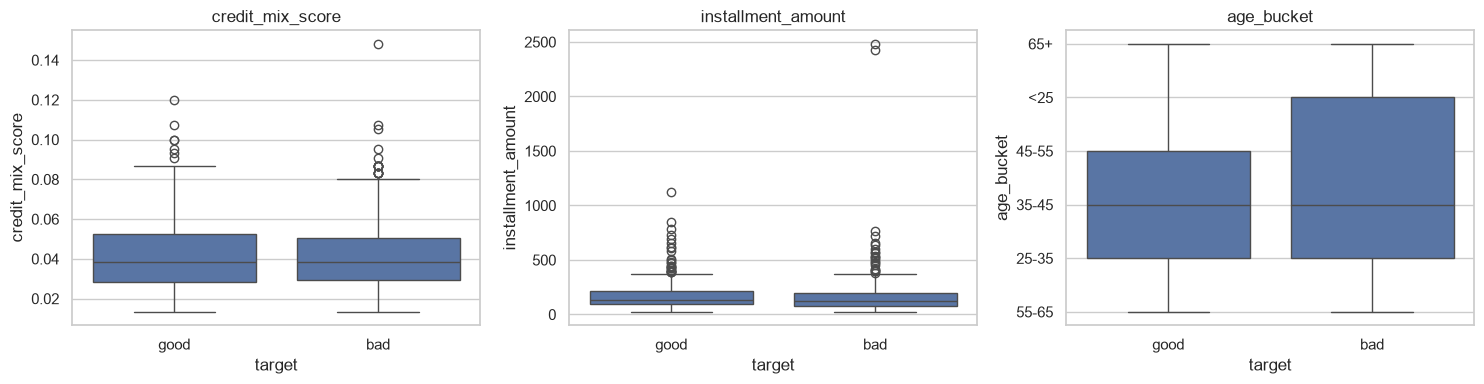

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax,col in zip(axes,['credit_mix_score','installment_amount','age_bucket']):
    sns.boxplot(data=df_features,x='target',y=col,ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


# Confirm numeric vs categorical split used by model pipeline

In [7]:
numeric_features,categorical_features=get_feature_lists(df_features,target_col='target')
print('Numeric features:',numeric_features)
print('Categorical features:',categorical_features)

Numeric features: ['month_duration', 'credit_amount', 'payment_to_income_ratio', 'residence_since', 'age', 'n_credits', 'n_guarantors', 'credit_mix_score', 'installment_amount']
Categorical features: ['status_account', 'credit_history', 'purpose', 'status_savings', 'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral', 'other_installment_plans', 'housing', 'job', 'telephone', 'is_foreign_worker', 'age_bucket']


# Correlation between categorical features

In [8]:
from src.evaluate import plot_categorical_association
categorical_cols=categorical_features+['target']
assoc_matrix=plot_categorical_association(df_features,columns=categorical_cols)
assoc_matrix

2026-07-08 18:16:18 | INFO     | src.evaluate | Saved categorical association heatmap -> C:\Users\mohit\Credit-scoring-model\outputs\figures\categorical_association.png


,status_account,credit_history,purpose,status_savings,years_employment,status_and_sex,secondary_obligor,collateral,other_installment_plans,housing,job,telephone,is_foreign_worker,age_bucket,target
status_account,1.000000,0.127103,0.115314,0.164016,0.071392,0.038910,0.093775,0.052396,0.000000,0.082131,0.051549,0.059553,0.058305,0.082564,0.347619
credit_history,0.127103,1.000000,0.137812,0.033377,0.078513,0.067460,0.060504,0.048727,0.206069,0.073947,0.014227,0.033341,0.030170,0.096324,0.240302
purpose,0.115314,0.137812,1.000000,0.062941,0.076384,0.117689,0.135423,0.182900,0.107082,0.187704,0.179537,0.199263,0.136243,0.080358,0.156115
status_savings,0.164016,0.033377,0.062941,1.000000,0.056341,0.000000,0.072944,0.047551,0.000000,0.000000,0.020359,0.068267,0.000000,0.060245,0.179240
years_employment,0.071392,0.078513,0.076384,0.056341,1.000000,0.153889,0.054048,0.133023,0.030516,0.161097,0.305272,0.136707,0.051620,0.213389,0.119911
status_and_sex,0.038910,0.067460,0.117689,0.000000,0.153889,1.000000,0.000000,0.106996,0.020656,0.194792,0.054370,0.070363,0.040608,0.184596,0.081295
secondary_obligor,0.093775,0.060504,0.135423,0.072944,0.054048,0.000000,1.000000,0.131217,0.037571,0.038703,0.058955,0.061570,0.111932,0.000000,0.068176
collateral,0.052396,0.048727,0.182900,0.047551,0.133023,0.106996,0.131217,1.000000,0.060663,0.551012,0.186280,0.190158,0.131574,0.129315,0.144005
other_installment_plans,0.000000,0.206069,0.107082,0.000000,0.030516,0.020656,0.037571,0.060663,1.000000,0.077760,0.042664,0.000000,0.000000,0.000000,0.104154
housing,0.082131,0.073947,0.187704,0.000000,0.161097,0.194792,0.038703,0.551012,0.077760,1.000000,0.115021,0.109549,0.056033,0.257495,0.127334


In [9]:
save_csv(df_features, PROCESSED_DATA_PATH)
print(f'Processed data saved to {PROCESSED_DATA_PATH}')

Processed data saved to C:\Users\mohit\Credit-scoring-model\data\processed\processed_credit_data.csv
